# 04 · Nonstationary flood frequency at Brays Bayou

These seven LP-III structures use the same observed metric flood record.
Their location, scale and skew trends are explicit model choices. The eighth
case averages only three selected fits using fresh DIC weights.
Restart Kernel and Run All builds and estimates each model through BestFit.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from time import perf_counter
from math import exp
import pandas as pd
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
runtime = load_bestfit()
print(runtime)
from System import Array, Double, DateTime
from System.Collections.Generic import List
from Numerics.Data import ProbabilityOrdinates
from Numerics.Data.Statistics import Probability
from Numerics.Distributions import UnivariateDistributionType
from RMC.BestFit.Models import DataFrame, ExactData, ExactSeries, IntervalData, ThresholdData, UnivariateDistribution
from RMC.BestFit.Models.TrendFunctions.Support import TrendModelType
from RMC.BestFit.Analyses import (UnivariateAnalysis, CompositeAnalysis,
                                  WeightedUnivariateAnalysis, CompositeType, AverageMethod)
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Brays Bayou's observed record

Keep the metric series and source threshold window. The long raw USGS text is
provenance; model observations come from the decoded exact and threshold rows.

In [3]:
raw = load_raw("nsffa-brays-bayou-texas")
input_name = "USGS 08075000 Brays Bayou - Metric"
observed = raw["inputs"][input_name]
frame = DataFrame()
frame.ExactSeries = ExactSeries()
for row in observed["series"]["ExactSeries"]:
    point = ExactData(DateTime.Parse(row["DateTime"]), float(row["Value"]))
    point.Index = int(row["Index"])
    point.IsLowOutlier = row.get("IsLowOutlier", "False") == "True"
    frame.ExactSeries.Add(point)
for row in observed["series"]["IntervalSeries"]:
    frame.IntervalSeries.Add(IntervalData(int(row["Index"]), float(row["LowerValue"]),
                                          float(row["Value"]), float(row["UpperValue"])))
for row in observed["series"]["ThresholdSeries"]:
    threshold = ThresholdData(int(row["StartIndex"]), int(row["EndIndex"]), float(row["Value"]))
    threshold.NumberAbove = int(row["NumberAbove"])
    frame.ThresholdSeries.Add(threshold)
frame.PlottingParameter = float(observed["attributes"]["PlottingParameter"])
frame.CalculatePlottingPositions()
display(pd.DataFrame(observed["series"]["ExactSeries"]).head())
print({"exact": frame.ExactSeries.Count, "threshold windows": frame.ThresholdSeries.Count})

,DateTime,Index,IsLowOutlier,Value
0,0001-01-01T00:00:00.0000000,1929,False,314
1,0001-01-01T00:00:00.0000000,1936,False,187
2,0001-01-01T00:00:00.0000000,1936,False,36
3,0001-01-01T00:00:00.0000000,1938,False,128
4,0001-01-01T00:00:00.0000000,1939,False,193


{'exact': 90, 'threshold windows': 1}


## Seven explicit trend structures

LP-III trend coordinates are mean of log, standard deviation of log, then
skew of log. All source trends begin in 1929 and are evaluated at 2024.
The bounds and uniform priors are generated by BestFit's SetTrendModel from
these same observations; they are inspected below before estimation.

In [4]:
trend_specs = [
    ("NSFFA - Constant", "Constant", "Constant", "Constant"),
    ("NSFFA - Linear", "Linear", "Constant", "Constant"),
    ("NSFFA - Logistic", "Logistic", "Constant", "Constant"),
    ("NSFFA - Step", "StepFunction", "Constant", "Constant"),
    ("NSFFA - Linear - Logistic", "Linear", "Logistic", "Constant"),
    ("NSFFA - Logistic - Logistic", "Logistic", "Logistic", "Constant"),
    ("NSFFA - Step - Logistic", "StepFunction", "Logistic", "Constant"),
]
mcmc_design = {
    "NSFFA - Constant": (6, 30, 300, .971630931303994, 10000),
    "NSFFA - Linear": (8, 40, 400, .8414570696119914, 10000),
    "NSFFA - Logistic": (8, 40, 400, .8414570696119914, 10000),
    "NSFFA - Step": (10, 50, 500, .7526220831200742, 10000),
    "NSFFA - Linear - Logistic": (10, 50, 500, .7526220831200742, 10000),
    "NSFFA - Logistic - Logistic": (10, 50, 500, .7526220831200742, 20000),
    "NSFFA - Step - Logistic": (12, 60, 600, .6870468203356547, 10000),
}
aep = [1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, .0001, .0002, .0005,
       .001, .002, .005, .01, .02, .05, .1, .2, .3, .5, .7, .8, .9, .95, .98, .99]
analyses, models, timings = {}, {}, {}
for name, mean_trend, scale_trend, skew_trend in trend_specs:
    chains, thinning, initial, jump, output_length = mcmc_design[name]
    model = UnivariateDistribution(frame, UnivariateDistributionType.LogPearsonTypeIII)
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    model.IsNonstationary = True
    model.SetTrendModel(0, getattr(TrendModelType, mean_trend))
    model.SetTrendModel(1, getattr(TrendModelType, scale_trend))
    model.SetTrendModel(2, getattr(TrendModelType, skew_trend))
    model.ParameterTimeIndex = 2024
    model.Alpha = .5
    for trend in model.TrendModels:
        trend.StartIndex = 1929
    analysis = UnivariateAnalysis(model)
    analysis.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
    bayes = analysis.BayesianAnalysis
    bayes.UseSimulationDefaults = True
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.NumberOfChains = chains
    bayes.ThinningInterval = thinning
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.UseAdvancedSimulationDefaults = True
    bayes.InitialIterations = initial
    bayes.Jump = jump
    bayes.JumpThreshold = .1
    bayes.SnookerThreshold = .1
    bayes.Noise = 1e-12
    bayes.Scale = 5.6644
    bayes.Beta = .05
    bayes.MaxTreeDepth = 10
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = output_length
    bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name], models[name] = analysis, model
    record_run(name, analysis, timings[name], raw=raw, model=model)

NSFFA - Constant: completed in 8.06 s. Execution alone does not establish convergence or scientific acceptance.


NSFFA - Linear: completed in 10.01 s. Execution alone does not establish convergence or scientific acceptance.


NSFFA - Logistic: completed in 8.92 s. Execution alone does not establish convergence or scientific acceptance.


NSFFA - Step: completed in 14.06 s. Execution alone does not establish convergence or scientific acceptance.


NSFFA - Linear - Logistic: completed in 15.14 s. Execution alone does not establish convergence or scientific acceptance.


NSFFA - Logistic - Logistic: completed in 19.89 s. Execution alone does not establish convergence or scientific acceptance.


NSFFA - Step - Logistic: completed in 27.64 s. Execution alone does not establish convergence or scientific acceptance.


## Compare the fitted structures at 2024

A changing return level must be interpreted at its specified year. The
chronology is a separate computed output, not a timeless frequency curve.

In [5]:
rows = []
for name, mean_trend, scale_trend, skew_trend in trend_specs:
    model, analysis = models[name], analyses[name]
    rows.append({"Case": name, "Location trend": mean_trend, "Scale trend": scale_trend,
                 "Skew trend": skew_trend, "Year": model.ParameterTimeIndex,
                 "DIC": float(analysis.BayesianAnalysis.DIC),
                 "1% AEP parameter point estimate": float(analysis.AnalysisResults.ModeCurve[aep.index(.01)])})
display(pd.DataFrame(rows))
diagnostics = []
for name, *_ in trend_specs:
    result = analyses[name].BayesianAnalysis.Results
    for i, parameter in enumerate(result.ParameterResults):
        stats = parameter.SummaryStatistics
        diagnostics.append({"Case": name, "Parameter index": i,
                            "R-hat": float(stats.Rhat), "ESS": float(stats.ESS)})
display(pd.DataFrame(diagnostics))
display(pd.DataFrame([
    {"Trend": str(trend.Type), "Coefficient": str(parameter.Name),
     "Lower": float(parameter.LowerBound), "Upper": float(parameter.UpperBound)}
    for trend in models["NSFFA - Step - Logistic"].TrendModels for parameter in trend.Parameters]))

,Case,Location trend,Scale trend,Skew trend,Year,DIC,1% AEP parameter point estimate
0,NSFFA - Constant,Constant,Constant,Constant,2024,1228.346863,992.121614
1,NSFFA - Linear,Linear,Constant,Constant,2024,1180.365434,2290.873668
2,NSFFA - Logistic,Logistic,Constant,Constant,2024,1178.943038,2565.011708
3,NSFFA - Step,StepFunction,Constant,Constant,2024,1158.119559,1111.165195
4,NSFFA - Linear - Logistic,Linear,Logistic,Constant,2024,1172.296182,1445.905592
5,NSFFA - Logistic - Logistic,Logistic,Logistic,Constant,2024,1161.830991,1175.090331
6,NSFFA - Step - Logistic,StepFunction,Logistic,Constant,2024,1154.834404,972.380921


,Case,Parameter index,R-hat,ESS
0,NSFFA - Constant,0,0.999973,8761.551694
1,NSFFA - Constant,1,0.999913,9554.747938
2,NSFFA - Constant,2,1.000061,8949.949703
3,NSFFA - Linear,0,1.000501,9763.515544
4,NSFFA - Linear,1,1.000040,9367.270783
5,NSFFA - Linear,2,1.000179,9785.219810
6,NSFFA - Linear,3,1.000106,9801.569276
7,NSFFA - Logistic,0,1.000754,7408.605898
8,NSFFA - Logistic,1,1.000382,7391.507750
9,NSFFA - Logistic,2,1.000206,8066.723258


,Trend,Coefficient,Lower,Upper
0,StepFunction,(μ₁),1.000000e+00,4.00
1,StepFunction,(μ₂),1.000000e+00,4.00
2,StepFunction,(tₛ),1.929000e+03,2024.00
3,Logistic,(α),1.110223e-16,2.00
4,Logistic,(β),-6.000000e-02,0.06
5,Constant,(α),-6.000000e+00,6.00


## DIC-weighted model average

This composite uses only the three saved child names below. Its weights come
from their freshly computed DIC values; it has no independent MCMC chain.

In [6]:
selected_names = ["NSFFA - Linear - Logistic", "NSFFA - Logistic - Logistic",
                  "NSFFA - Step - Logistic"]
children = List[WeightedUnivariateAnalysis]()
for name in selected_names:
    children.Add(WeightedUnivariateAnalysis(analyses[name], 1.0 / 3.0))
average = CompositeAnalysis(children)
average.CompositeDistributionType = CompositeType.ModelAverage
average.ModelAverageMethod = AverageMethod.DIC
average.Dependency = Probability.DependencyType.Independent
average.IsMaximum = True
average.ProbabilityOrdinates = ProbabilityOrdinates(Array[Double](aep))
average.BayesianAnalysis.PRNGSeed = 12345
average.BayesianAnalysis.OutputLength = 10000
average.BayesianAnalysis.CredibleIntervalWidth = .9
average.EstimateModelWeights()
assert abs(sum(float(item.Weight) for item in average.Analyses) - 1.0) < 1e-10
child_dic = [float(analyses[name].BayesianAnalysis.DIC) for name in selected_names]
relative_scores = [exp(-.5 * (score - min(child_dic))) for score in child_dic]
independent_weights = [score / sum(relative_scores) for score in relative_scores]
for item, expected in zip(average.Analyses, independent_weights):
    assert abs(float(item.Weight) - expected) < 1e-12
started = perf_counter()
average.RunAsync(None).GetAwaiter().GetResult()
timings["Bayesian Model Average"] = perf_counter() - started
analyses["Bayesian Model Average"] = average
record_run("Bayesian Model Average", average, timings["Bayesian Model Average"], raw=raw)
display(pd.DataFrame([{"Child": name, "Fresh DIC weight": float(average.Analyses[i].Weight)}
                      for i, name in enumerate(selected_names)]))

Bayesian Model Average: completed in 2.93 s. Execution alone does not establish convergence or scientific acceptance.


,Child,Fresh DIC weight
0,NSFFA - Linear - Logistic,0.000157
1,NSFFA - Logistic - Logistic,0.029356
2,NSFFA - Step - Logistic,0.970487


## Visualize fresh conditional curves and chronology

Higher model flexibility does not identify a causal driver. The average covers
only the selected three structures and their fitted weights.

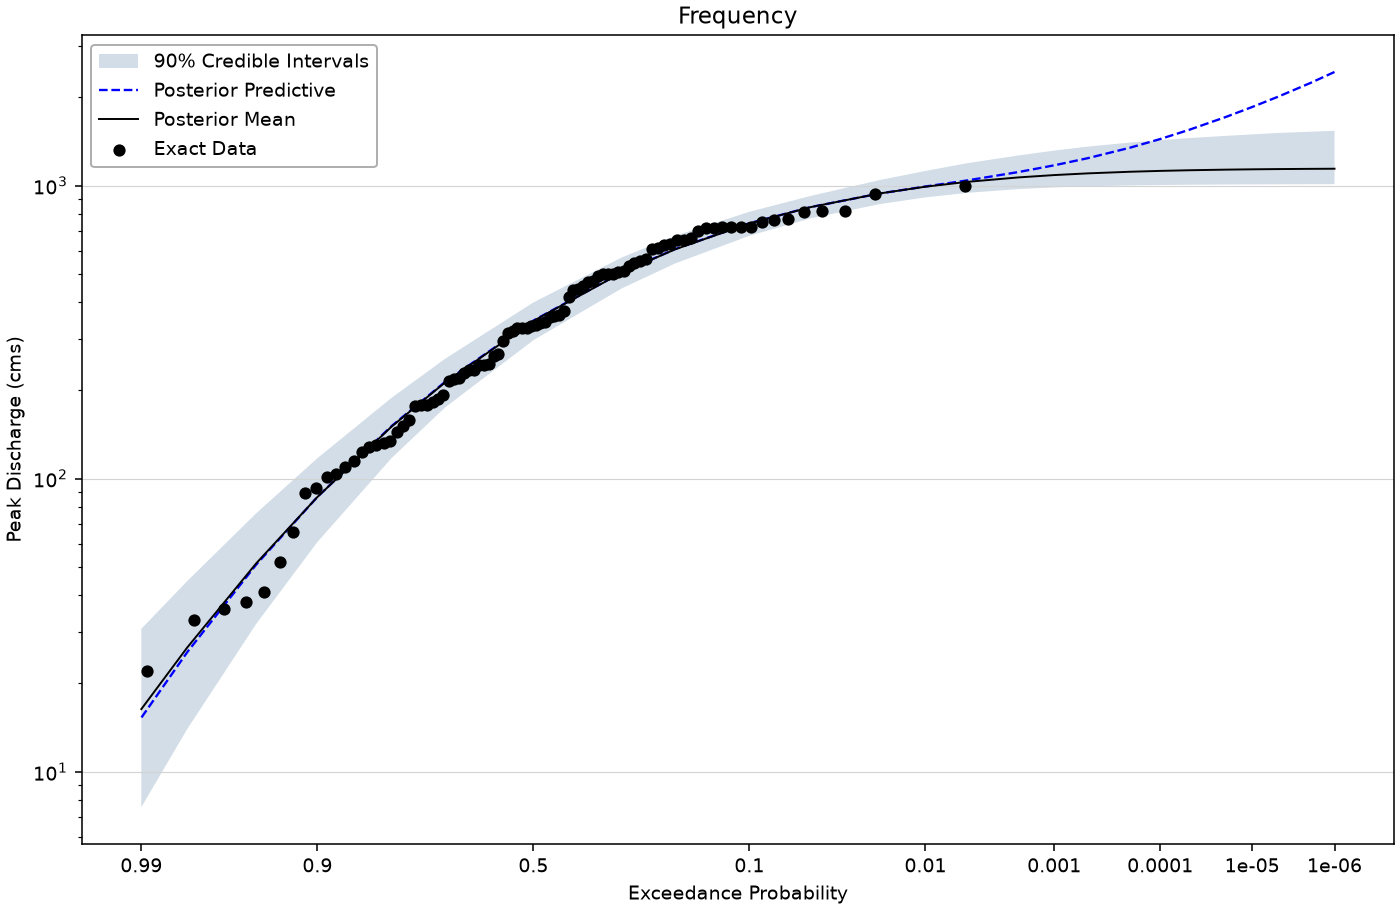

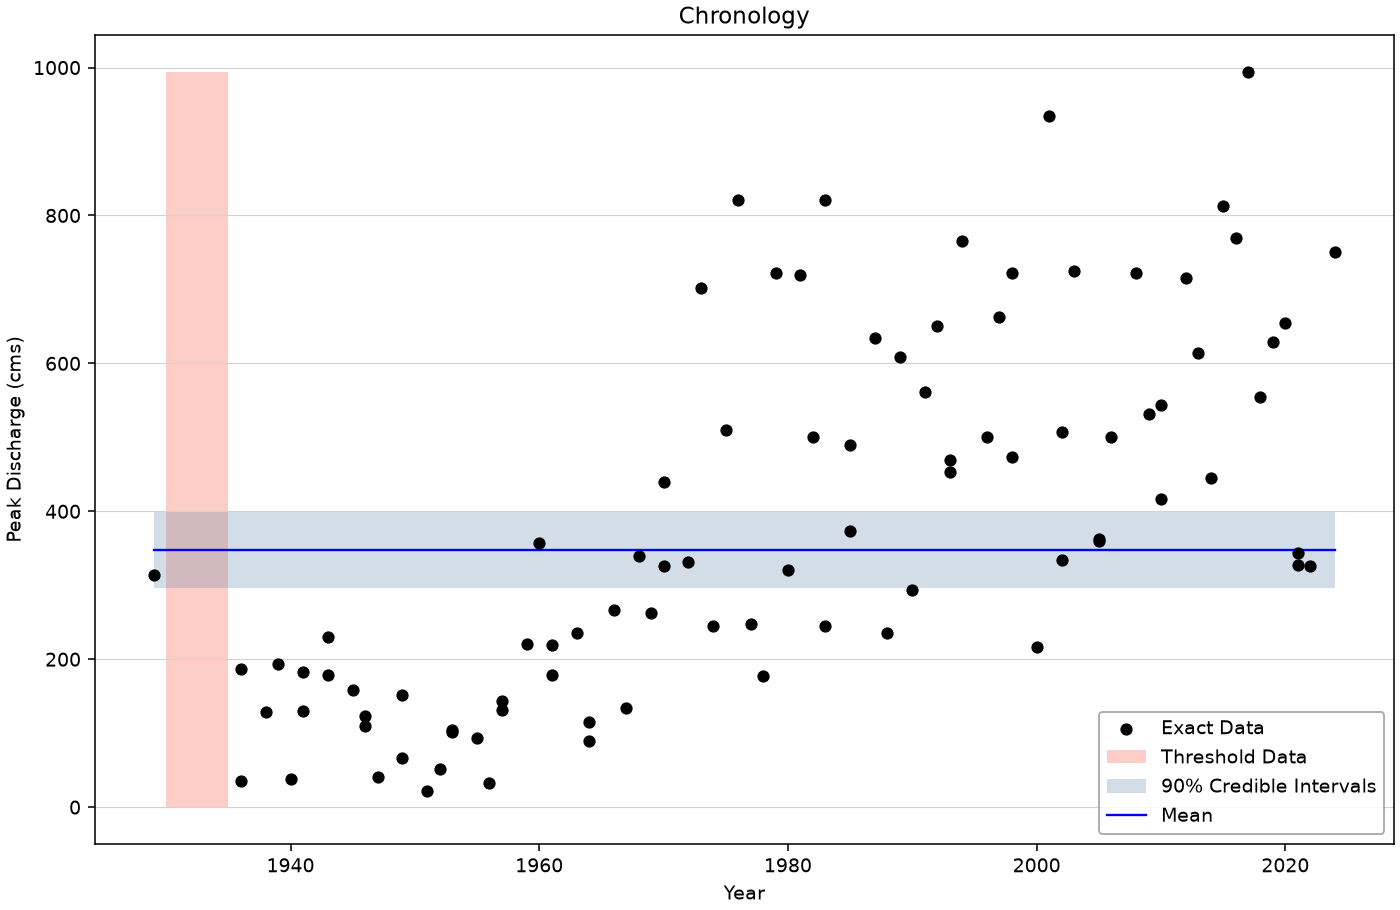

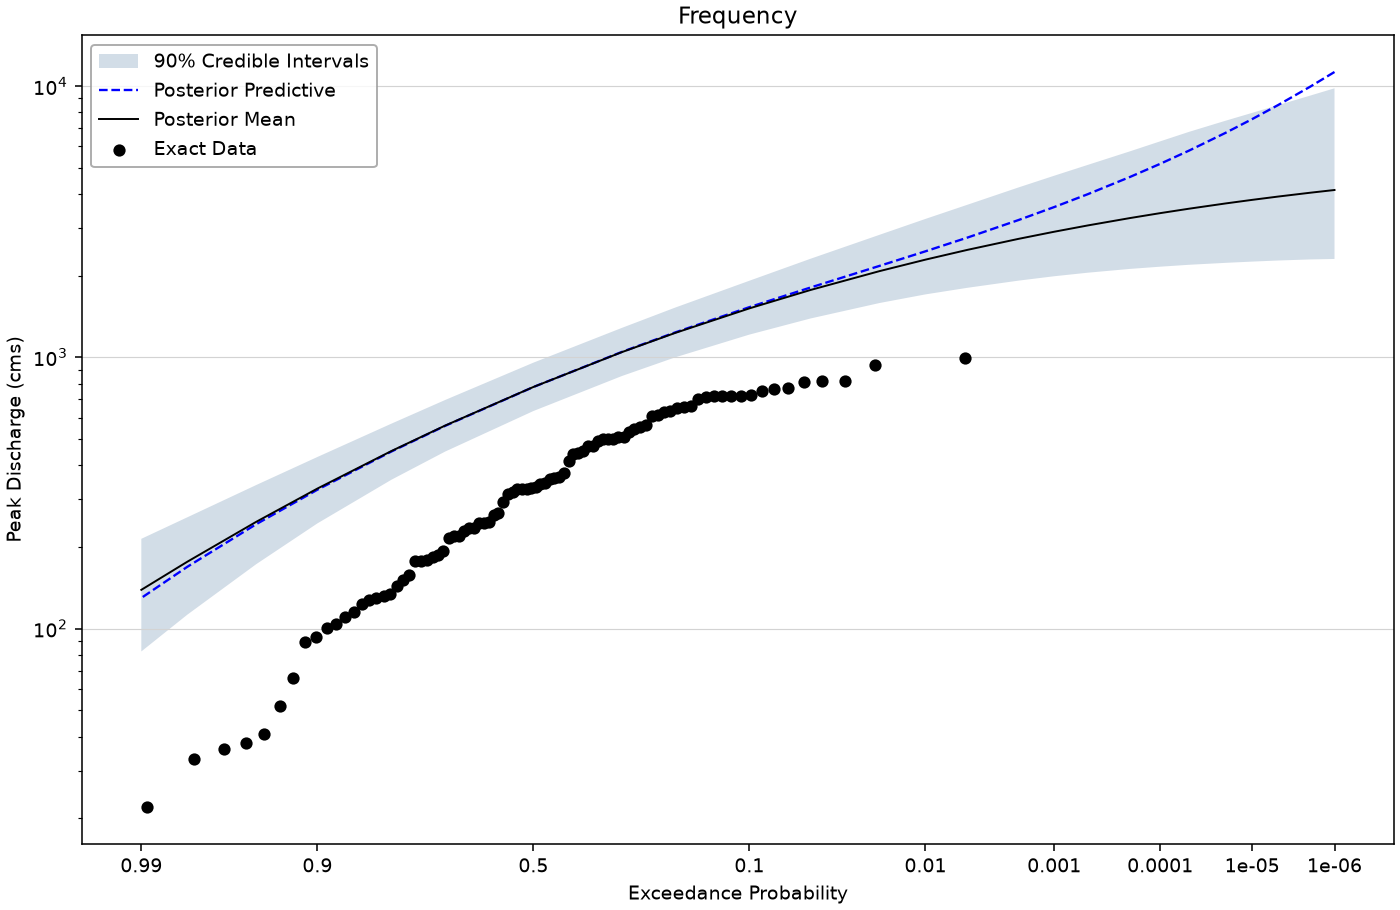

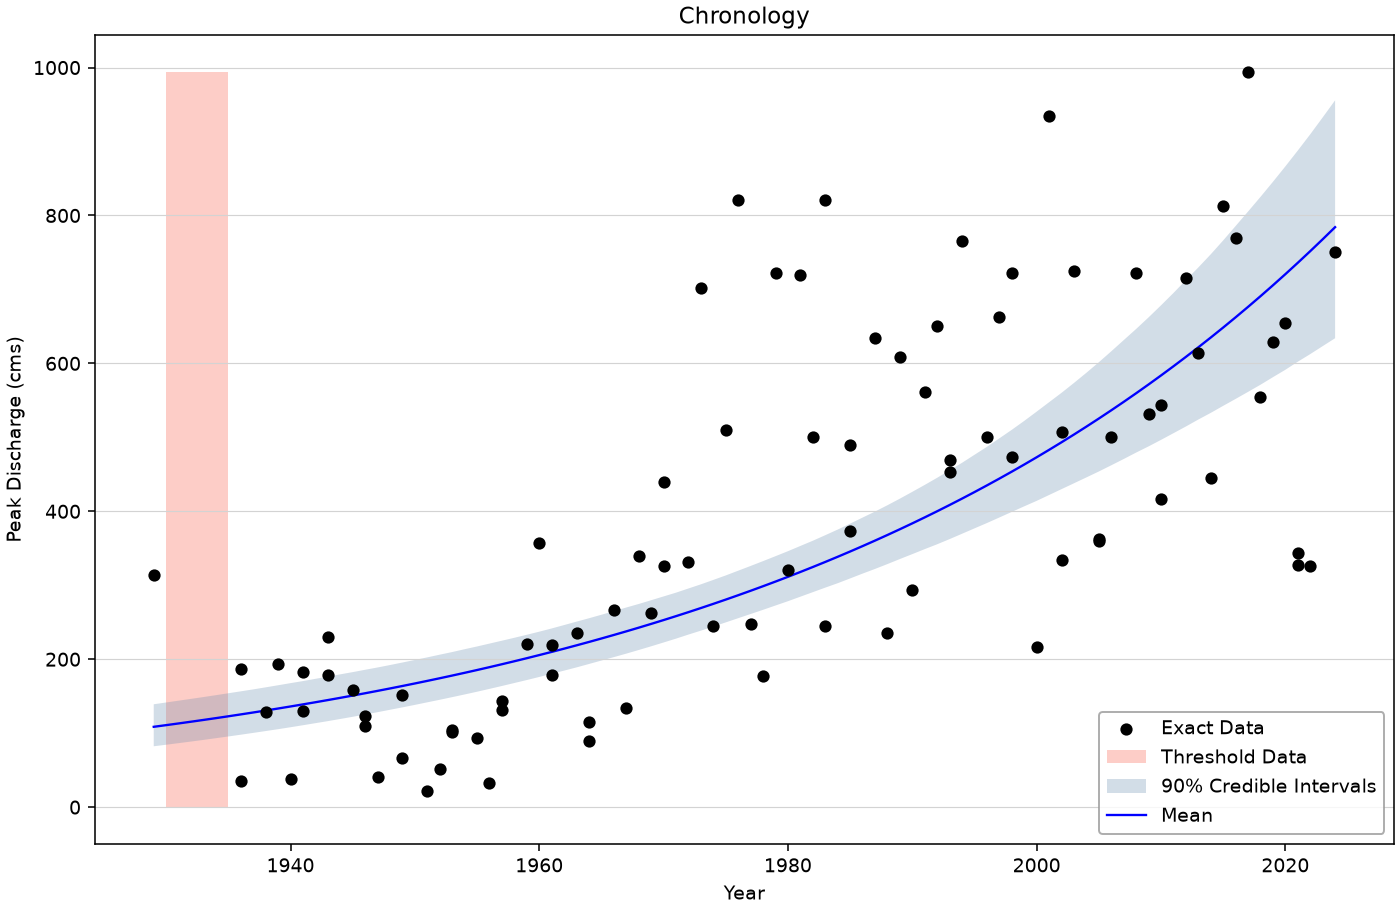

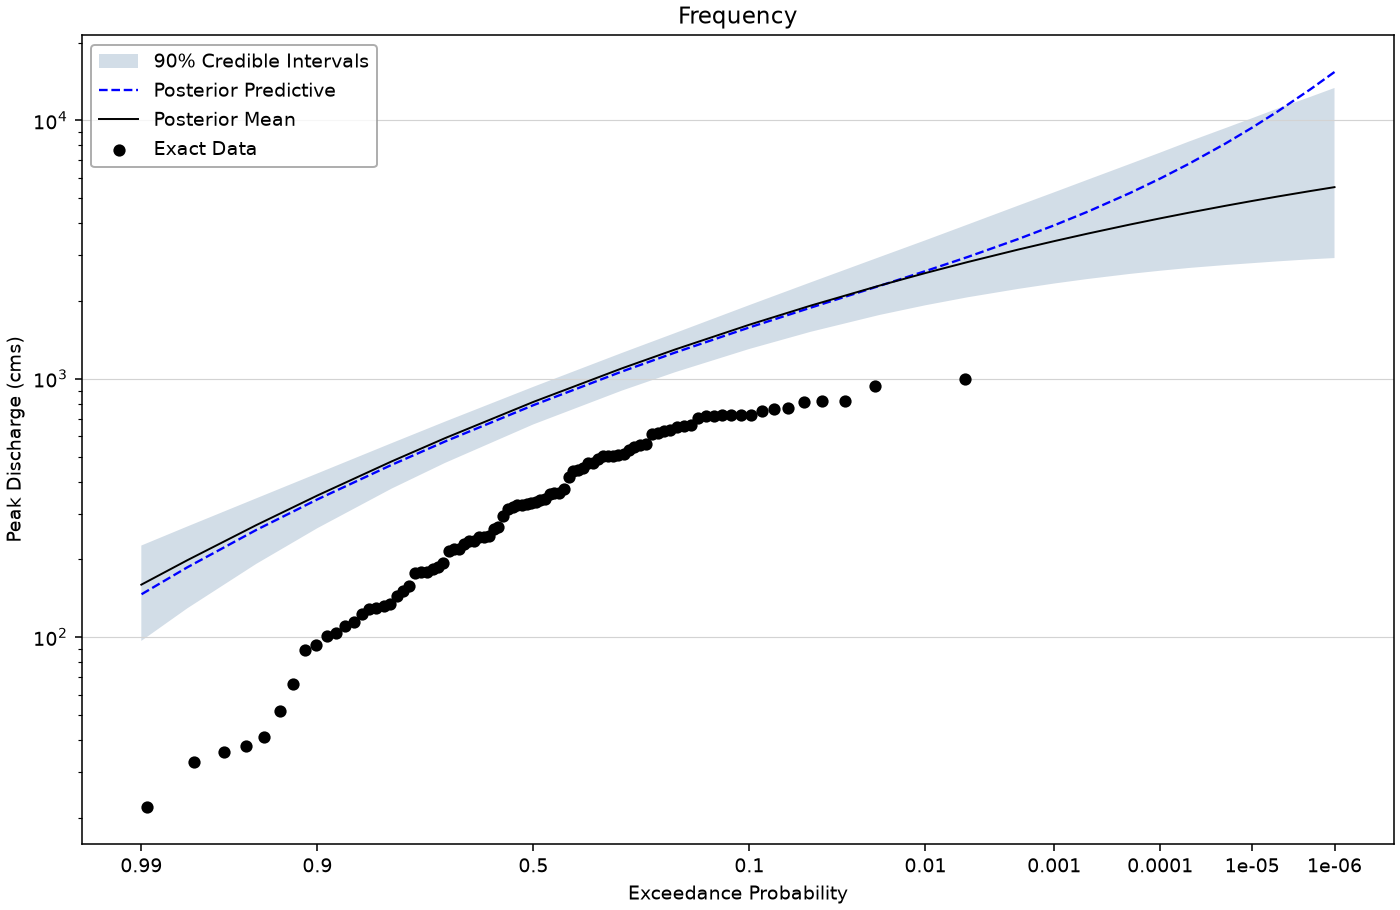

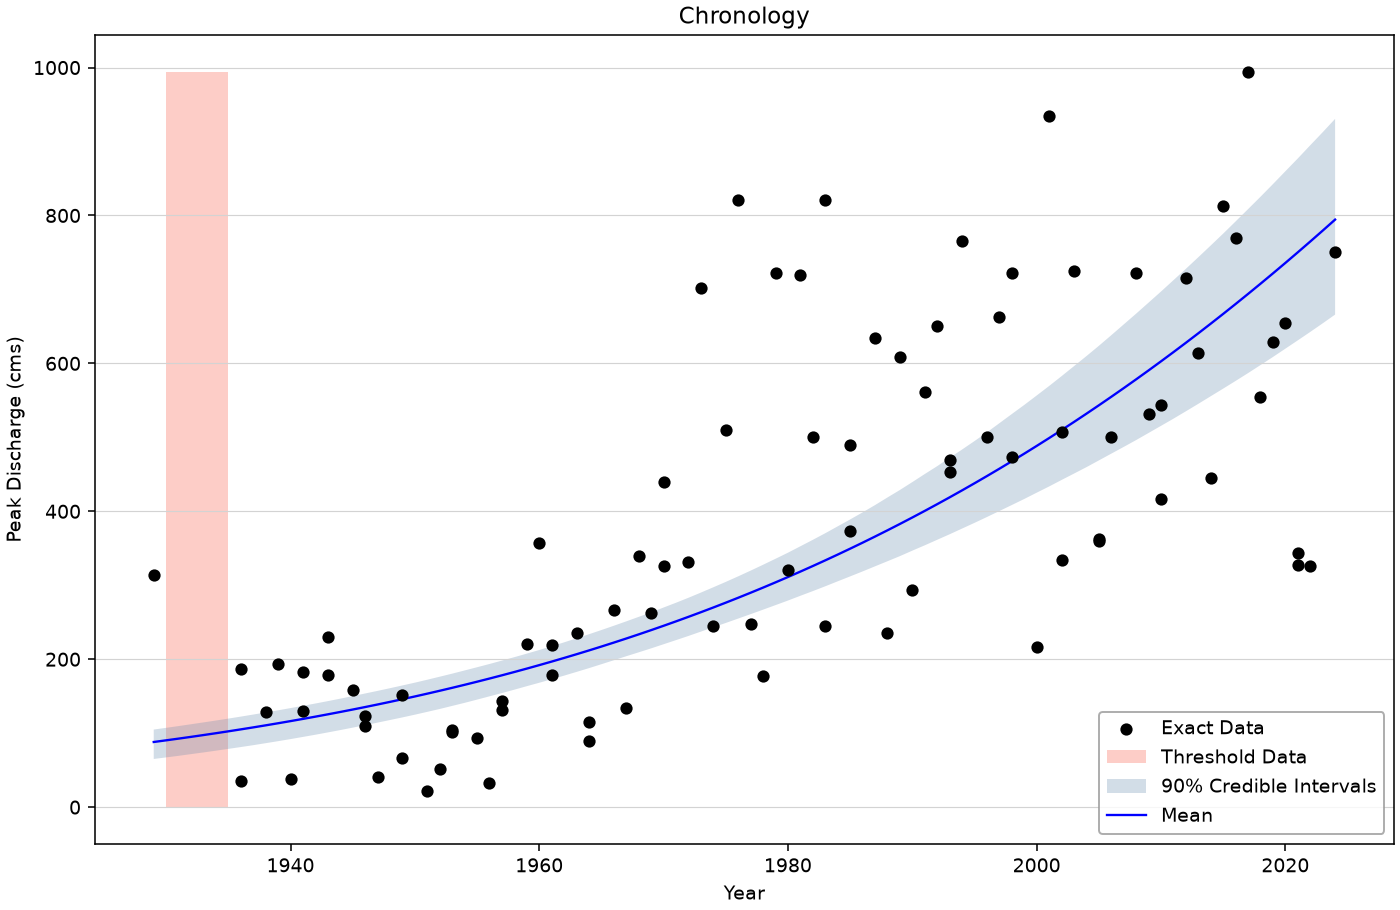

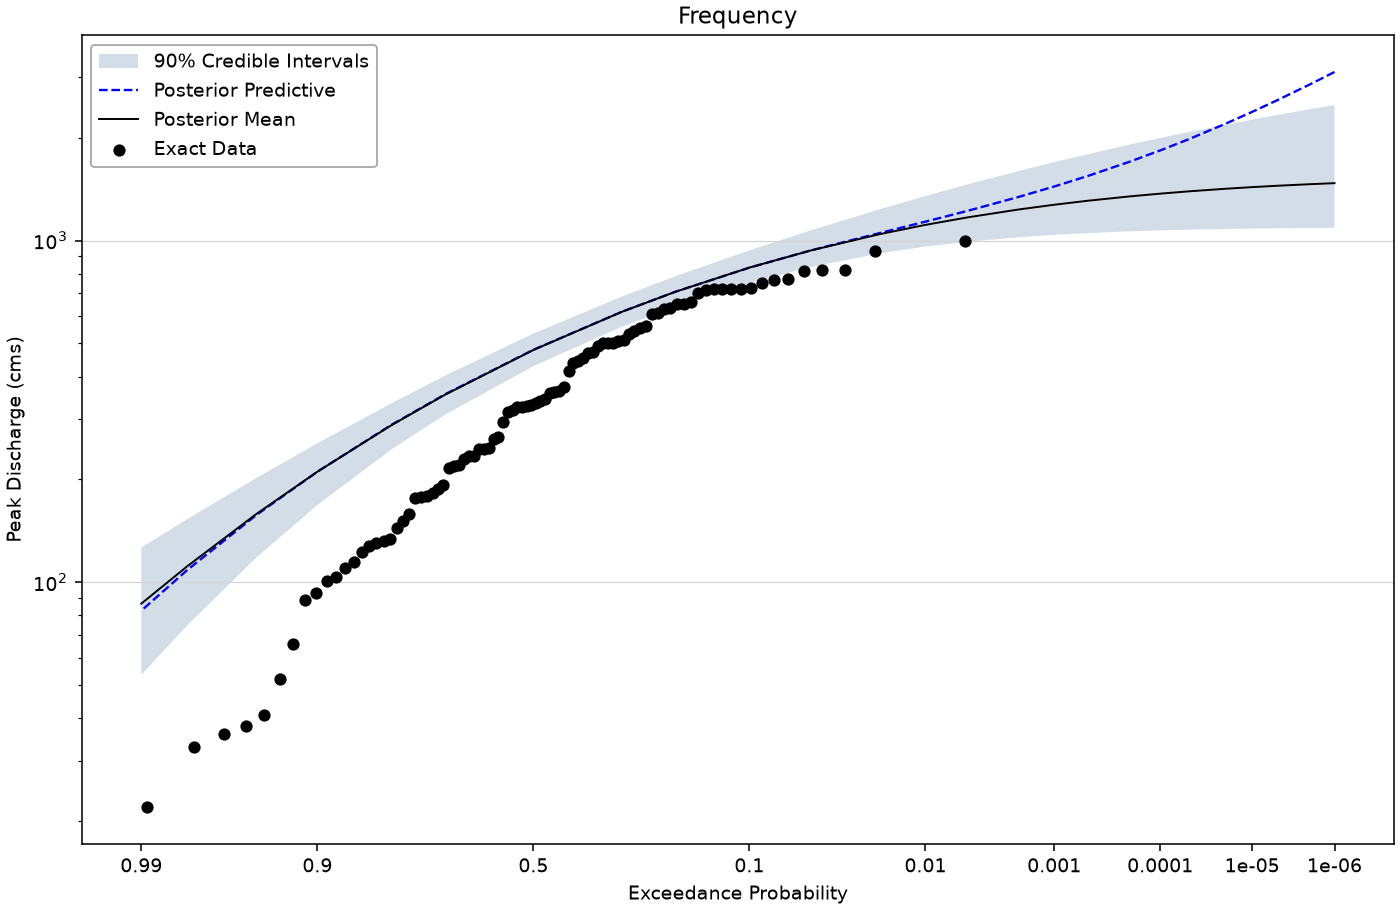

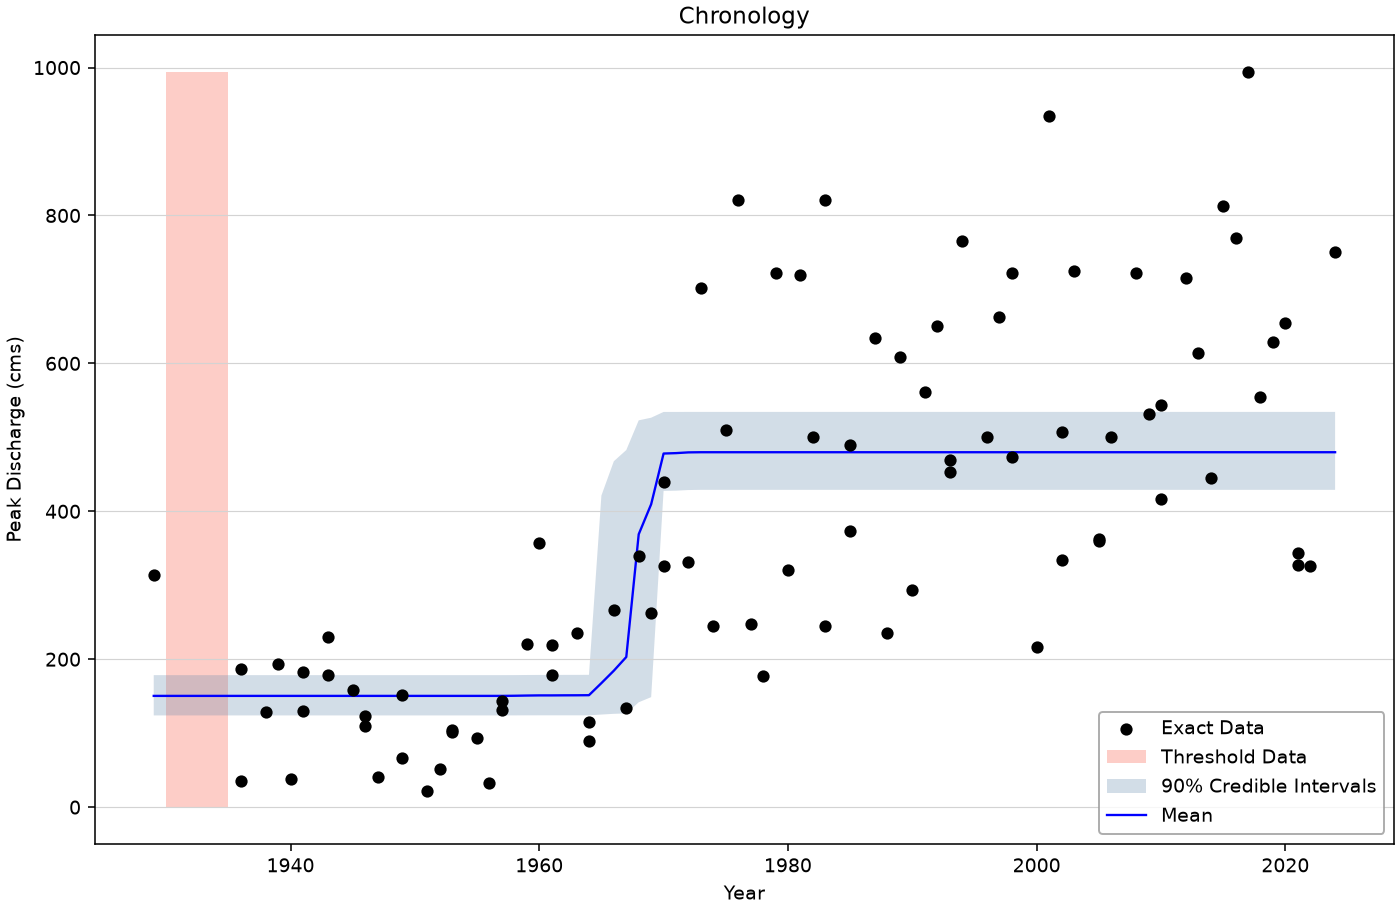

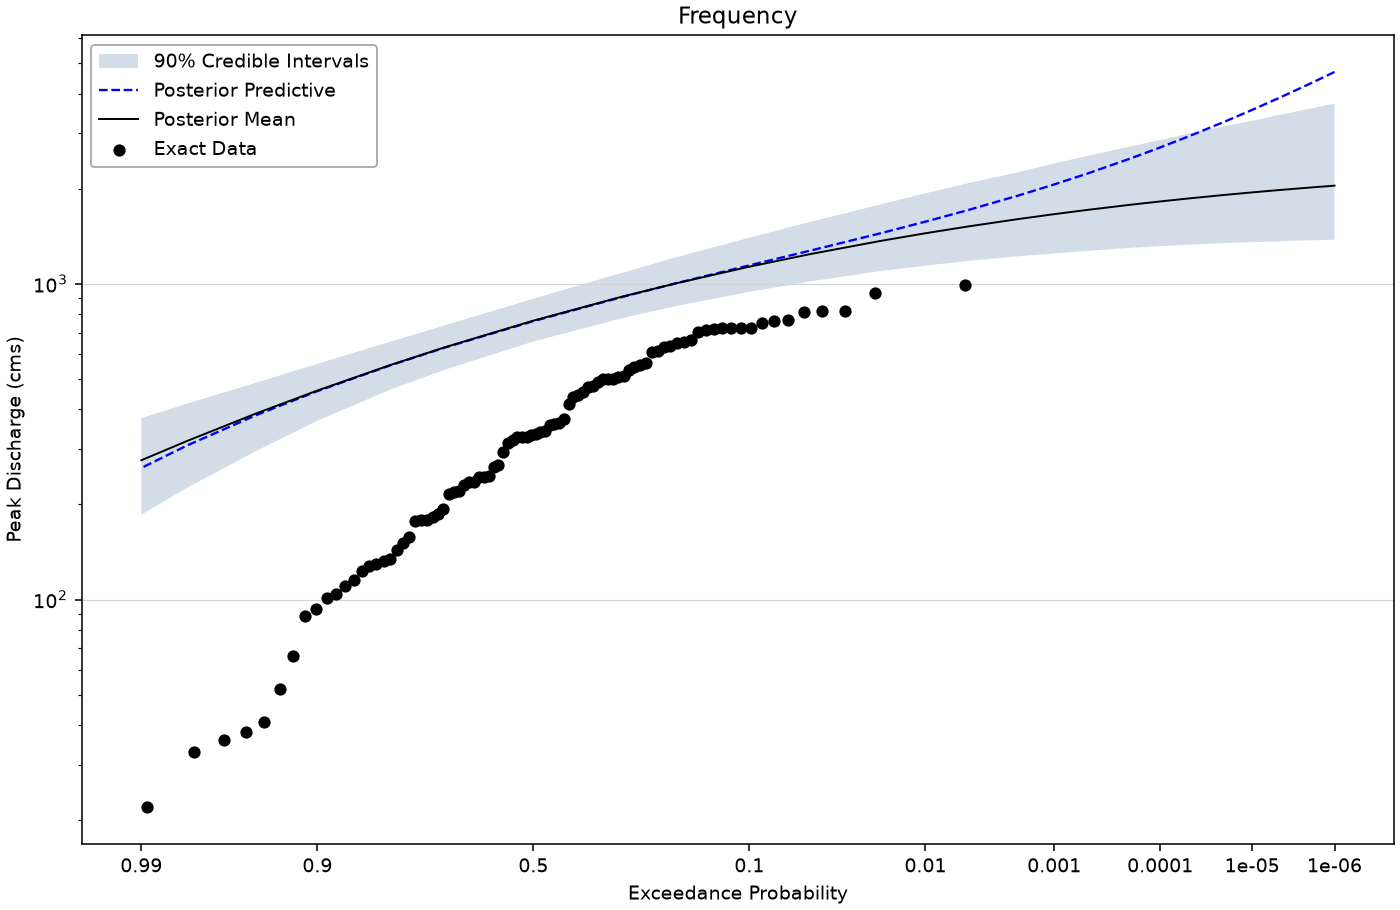

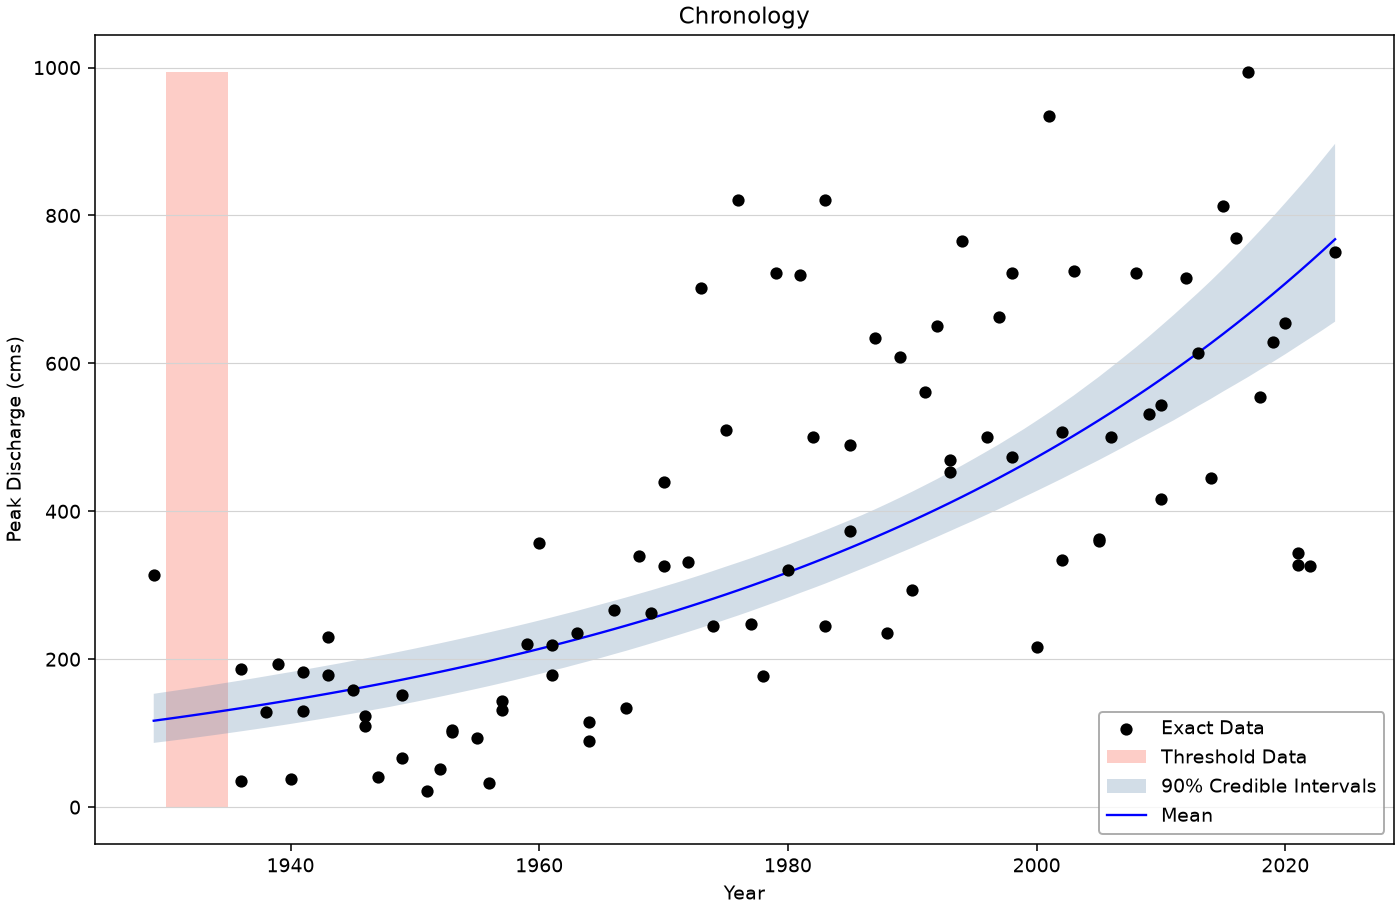

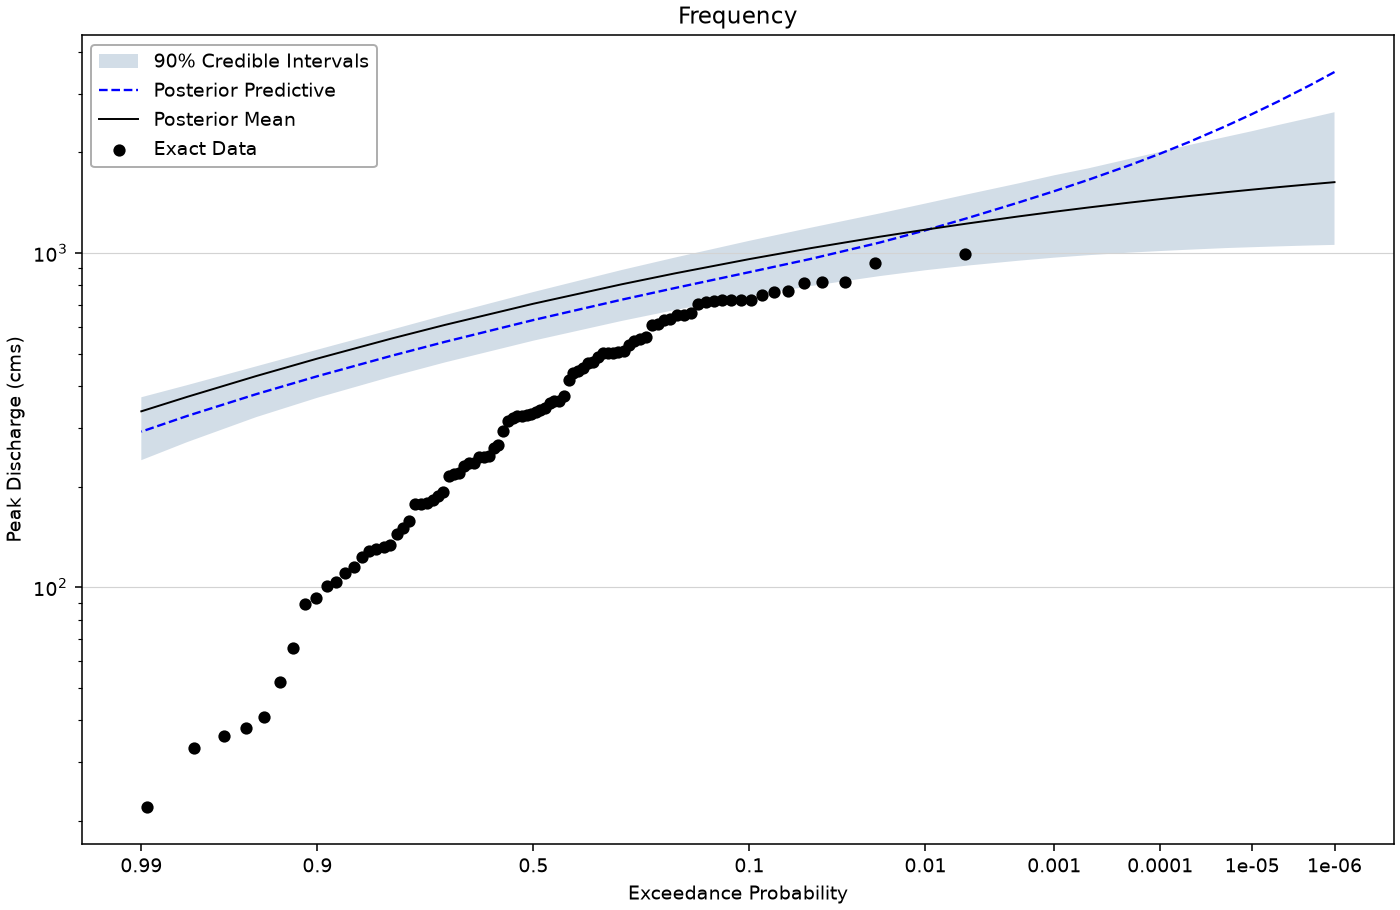

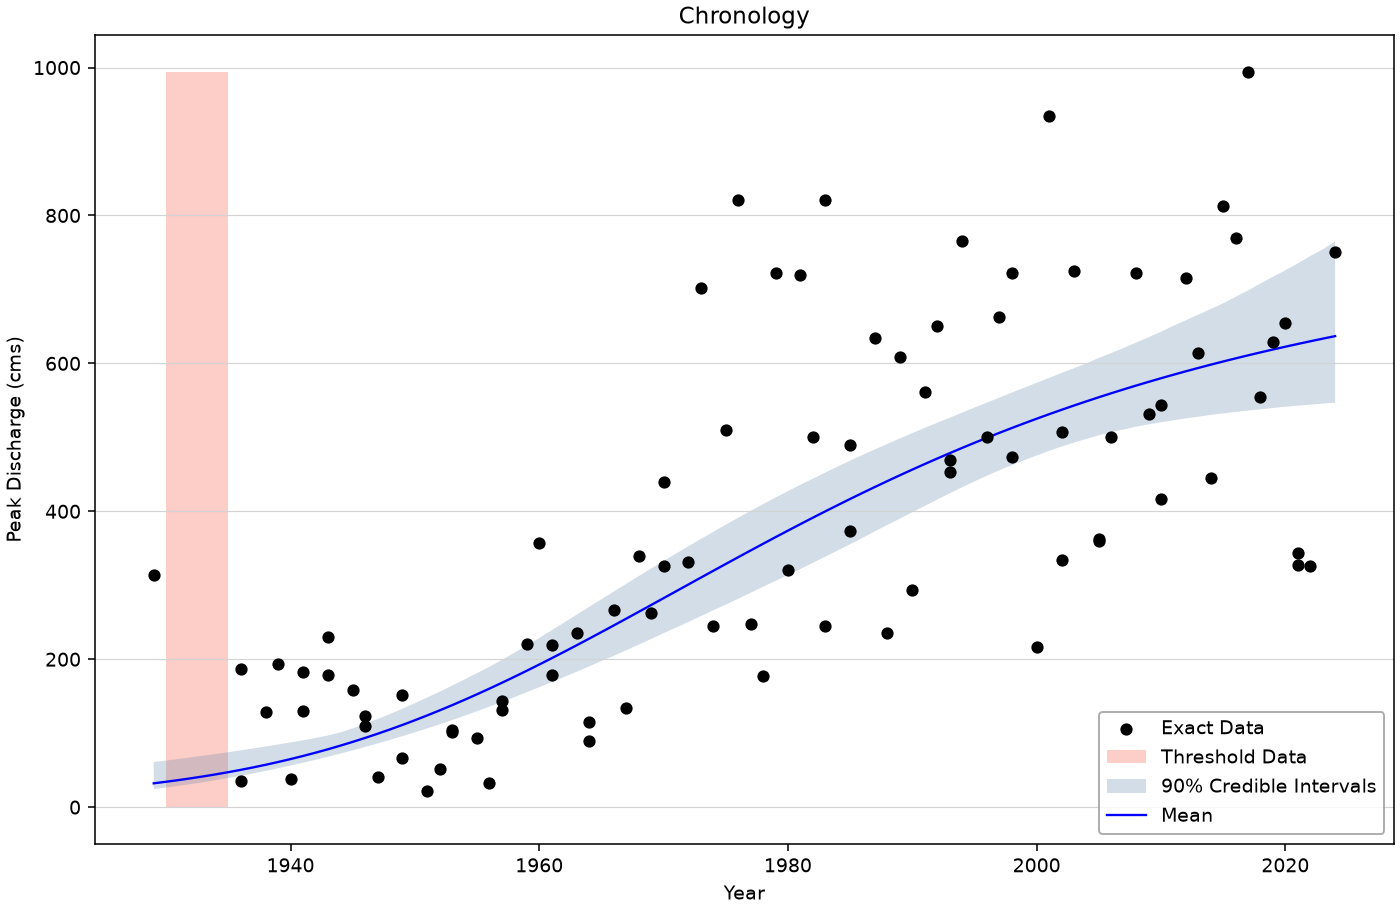

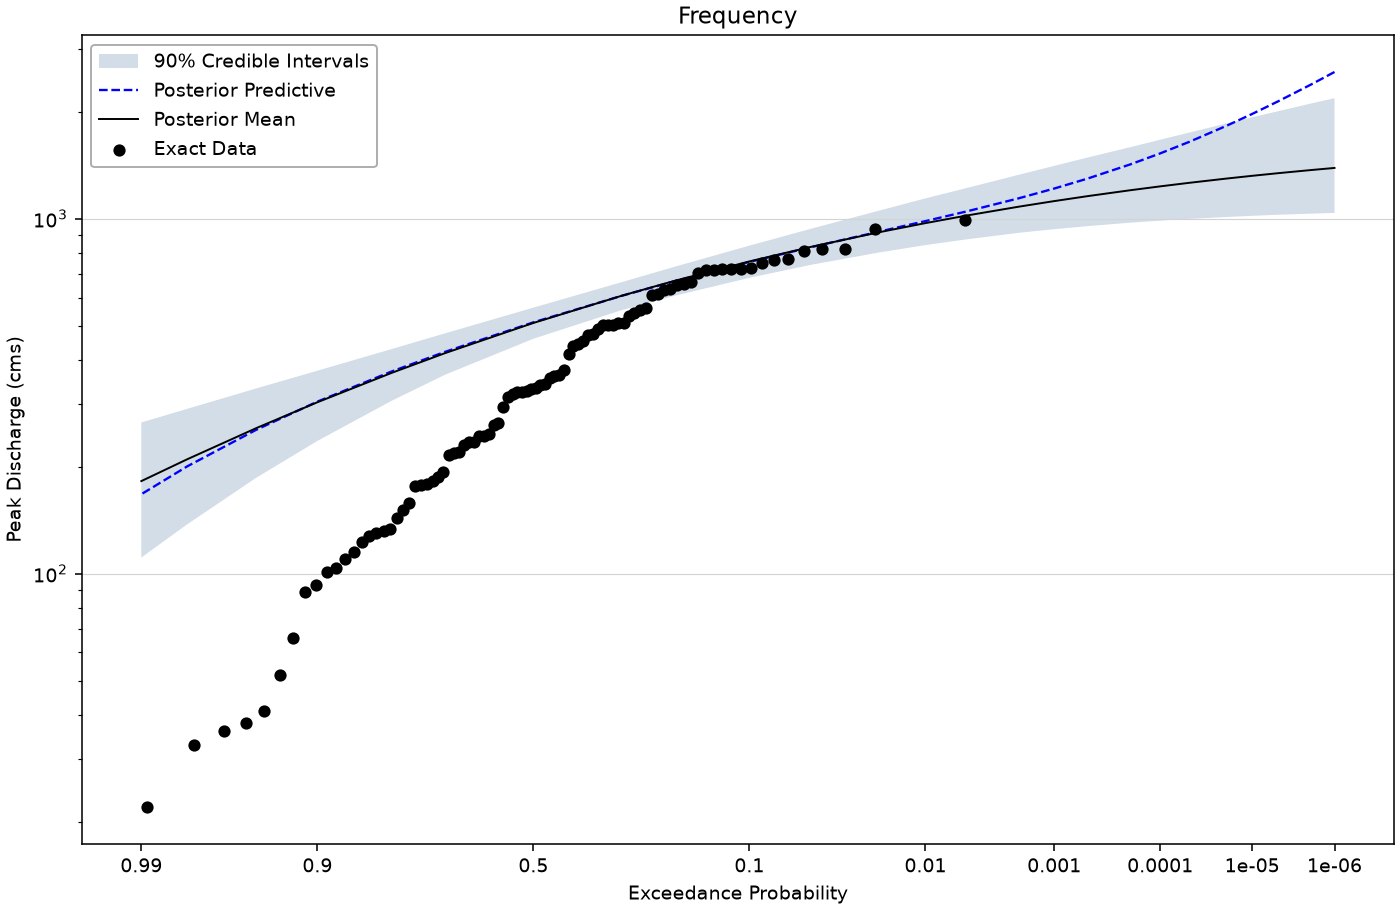

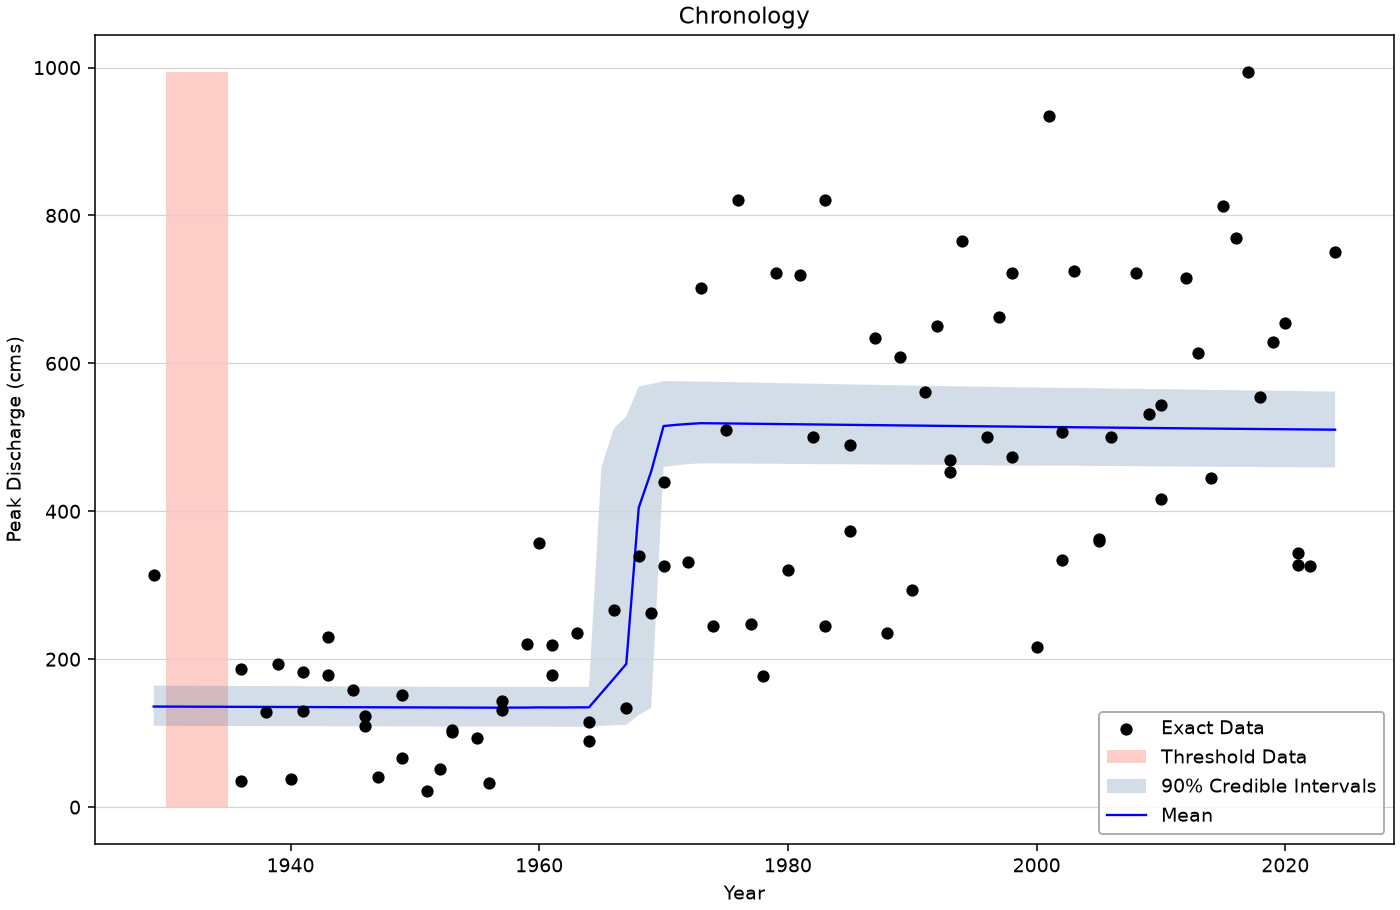

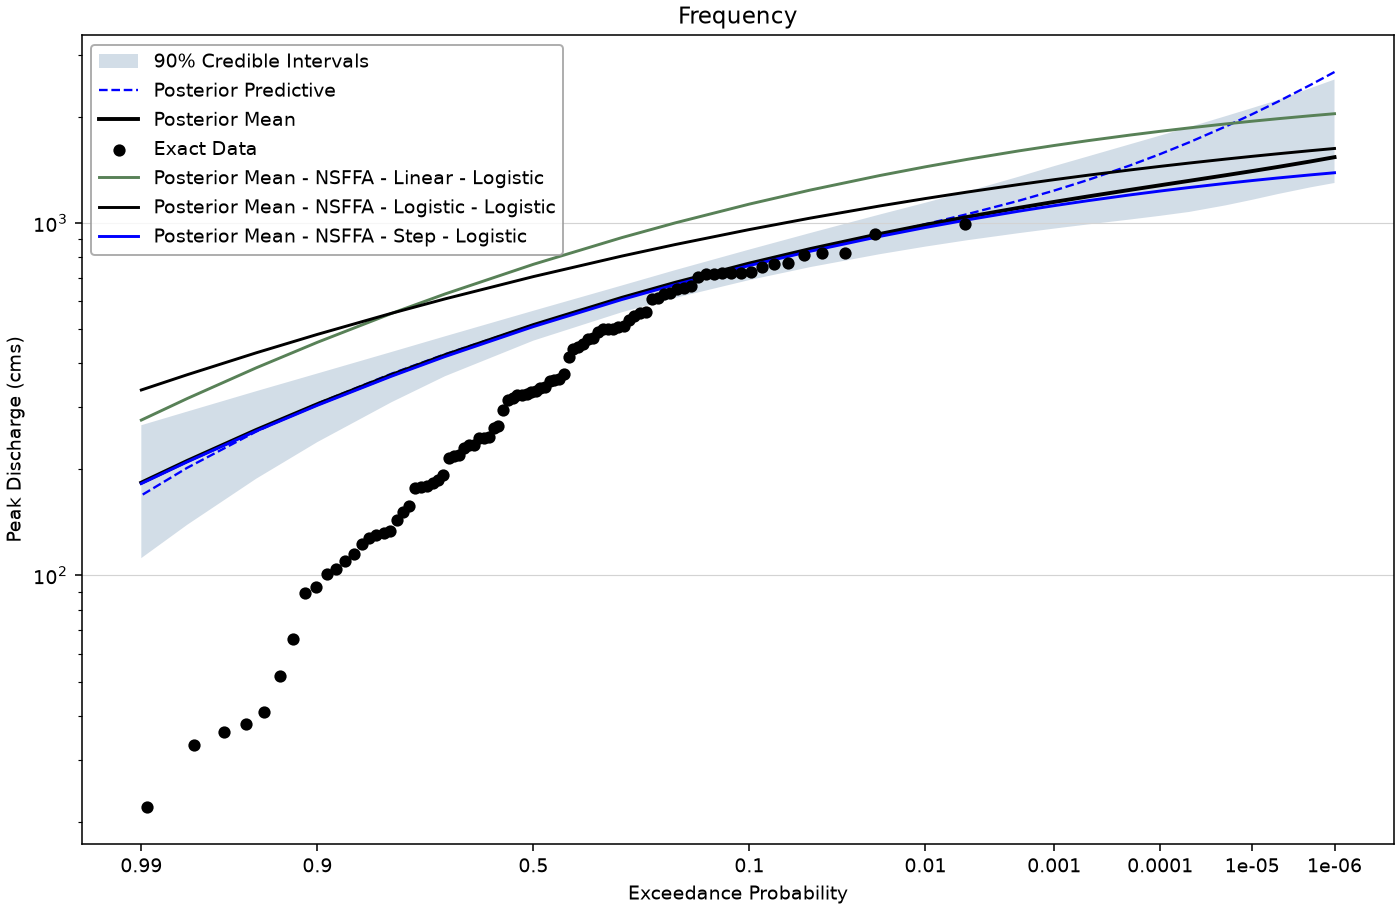

In [7]:
specs, contexts = {}, {}
for name, _, _, _ in trend_specs:
    context = plot_context(analyses[name], models[name], name=name, raw=raw,
                           frame=frame, metadata=observed["metadata"])
    contexts[name] = context
    specs[name] = plots(context)
    show(specs[name]["frequency"])
    if "chronology" in specs[name]:
        show(specs[name]["chronology"])
average_context = plot_context(average, name="Bayesian Model Average", raw=raw, frame=frame,
                               metadata=observed["metadata"],
                               dependencies={name: contexts[name] for name in selected_names})
specs["Bayesian Model Average"] = plots(average_context)
show(specs["Bayesian Model Average"]["frequency"])

**Adapt this example:** retain observed dates and threshold context, then
choose and disclose trend forms, evaluation year and model-average membership.